In [1]:
#@title Install dependencies (first run only)
!pip -q install pycountry openpyxl

import re
import pycountry
import pandas as pd
import numpy as np
from pathlib import Path


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 40.3 MB/s eta 0:00:00


In [2]:
#@title Mount Google Drive and set base paths
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = Path('/content/drive/MyDrive/ai4trade')
RAW_PATH = BASE_DIR / 'data' / 'raw' / 'exports_2025_usa.xlsx'
OUT_PATH = BASE_DIR / 'data' / 'interim' / 'USA_exports_2025.parquet'

print(f"Reading from: {RAW_PATH}")
print(f"Will write to: {OUT_PATH}")


Mounted at /content/drive
Reading from: /content/drive/MyDrive/ai4trade/data/raw/exports_2025_usa.xlsx
Will write to: /content/drive/MyDrive/ai4trade/data/interim/USA_exports_2025.parquet


In [3]:
#@title Utility functions

def clean_hs6(x) -> str:
    """
    Coerce HS6 into a clean 6-char zero-padded string.
    Removes commas, apostrophes, spaces, dots; keeps only digits; zfill(6).
    """
    if pd.isna(x):
        return np.nan
    s = str(x)
    s = s.replace(",", "").replace("’", "").replace("'", "").replace(" ", "").replace(".", "")
    s = re.sub(r"[^0-9]", "", s)
    if s == "":
        return np.nan
    return s.zfill(6)[:6]

def derive_hs4(hs6: str) -> str:
    if pd.isna(hs6):
        return np.nan
    return str(hs6)[:4]

def parse_month_header(colname: str):
    """
    Parse common Trademap month headers like:
    'Jan 2025', 'Jan-2025', '2025-01', '2025 Jan', 'January 2025'.
    Returns Timestamp at first day of month or None (fallback handled later).
    """
    for fmt in [None, '%b %Y', '%b-%Y', '%Y-%m', '%Y %b', '%B %Y', '%B-%Y']:
        try:
            dt = pd.to_datetime(colname, format=fmt, errors='raise')
            return pd.Timestamp(year=dt.year, month=dt.month, day=1)
        except Exception:
            pass
    return None

def is_iso3(code: str) -> bool:
    try:
        return pycountry.countries.get(alpha_3=code.upper()) is not None
    except Exception:
        return False

def extract_partner_from_sheet(sheet_name: str, prefix="USA-") -> str:
    """
    Sheet names are 'USA-XXX'. Extract XXX and validate ISO3.
    Handles slight dash/space variations.
    """
    if not sheet_name.startswith(prefix):
        m = re.match(r"USA[\s\-–—_]+([A-Za-z]{3})$", sheet_name.strip())
        code = m.group(1).upper() if m else sheet_name.split("-")[-1].strip().upper()
    else:
        code = sheet_name.replace(prefix, "").strip().upper()
    return code


In [4]:
#@title Read Excel (all sheets) and validate partner ISO3 codes
xlsx = pd.read_excel(RAW_PATH, sheet_name=None, header=0, engine='openpyxl')

sheet_partners = {sheet: extract_partner_from_sheet(sheet) for sheet in xlsx.keys()}
invalid = [(sheet, code) for sheet, code in sheet_partners.items() if not is_iso3(code)]

print("Detected sheets and partners:")
for s, c in sheet_partners.items():
    print(f"  {s}  ->  {c} (ISO3={'OK' if is_iso3(c) else 'INVALID'})")

if invalid:
    msg = "Some sheet names don't map to valid ISO3 partners:\n" + \
          "\n".join([f"  - Sheet '{s}' → '{c}' (INVALID)" for s, c in invalid]) + \
          "\n\nPlease rename those sheets to 'USA-XXX' with a valid ISO3 code and rerun."
    raise ValueError(msg)


Detected sheets and partners:
  USA-CAN  ->  CAN (ISO3=OK)
  USA-MEX  ->  MEX (ISO3=OK)
  USA-CHN  ->  CHN (ISO3=OK)
  USA-NLD  ->  NLD (ISO3=OK)
  USA-JPN  ->  JPN (ISO3=OK)
  USA-GBR  ->  GBR (ISO3=OK)
  USA-DEU  ->  DEU (ISO3=OK)
  USA-KOR  ->  KOR (ISO3=OK)
  USA-BRA  ->  BRA (ISO3=OK)
  USA-SGP  ->  SGP (ISO3=OK)
  USA-FRA  ->  FRA (ISO3=OK)
  USA-TWN  ->  TWN (ISO3=OK)
  USA-IND  ->  IND (ISO3=OK)
  USA-BEL  ->  BEL (ISO3=OK)
  USA-AUS  ->  AUS (ISO3=OK)
  USA-ITA  ->  ITA (ISO3=OK)
  USA-HKG  ->  HKG (ISO3=OK)
  USA-CHE  ->  CHE (ISO3=OK)
  USA-ARE  ->  ARE (ISO3=OK)
  USA-ESP  ->  ESP (ISO3=OK)
  USA-MYS  ->  MYS (ISO3=OK)
  USA-CHL  ->  CHL (ISO3=OK)
  USA-COL  ->  COL (ISO3=OK)
  USA-IRL  ->  IRL (ISO3=OK)
  USA-THA  ->  THA (ISO3=OK)
  USA-TUR  ->  TUR (ISO3=OK)
  USA-ISR  ->  ISR (ISO3=OK)
  USA-SAU  ->  SAU (ISO3=OK)
  USA-DOM  ->  DOM (ISO3=OK)
  USA-PER  ->  PER (ISO3=OK)


In [5]:
#@title Function to normalize a single partner sheet (Exports)
def normalize_partner_sheet(df_raw: pd.DataFrame, partner_iso3: str) -> pd.DataFrame:
    """
    Steps:
      1) Drop 'Total' row if present.
      2) Clean HS6; derive HS4.
      3) Identify month columns and melt to long (Jan–Aug 2025; robust to header variants).
      4) Attach identifiers: origin=USA, destination=partner, trade_flow='Export'.
      5) Drop zeros AFTER HS4 derivation (sparsity control).
    """
    df = df_raw.copy()

    # Drop obvious 'Total' rows (often the second row)
    first_col = df.columns[0]
    df = df[~df[first_col].astype(str).str.contains(r'^total$', case=False, na=False)]

    # Clean HS6 and remove empties
    df[first_col] = df[first_col].map(clean_hs6)
    df = df[~df[first_col].isna()]

    # Month headers
    month_cols = [c for c in df.columns if c != first_col]
    parsed = {c: parse_month_header(str(c)) for c in month_cols}
    if any(v is None for v in parsed.values()):
        # Fallback to ordered Jan..Aug 2025 assumption (keep original order)
        months = pd.period_range('2025-01', '2025-08', freq='M')
        fallback = {c: pd.Timestamp(m.start_time) for c, m in zip(month_cols, months)}
        for c in month_cols:
            if parsed[c] is None:
                parsed[c] = fallback[c]

    # Reshape to long
    df_long = df.melt(id_vars=[first_col], value_vars=month_cols,
                      var_name='month_col', value_name='value')
    df_long['month'] = df_long['month_col'].map(parsed)
    df_long.drop(columns=['month_col'], inplace=True)

    # Numerics
    df_long['value'] = pd.to_numeric(df_long['value'], errors='coerce').fillna(0.0)

    # IDs & schema
    df_long = df_long.rename(columns={first_col: 'hs6'})
    df_long['hs4'] = df_long['hs6'].map(derive_hs4)
    df_long['origin'] = 'USA'
    df_long['destination'] = partner_iso3
    df_long['trade_flow'] = 'Export'

    # Drop zeros after HS4 derivation
    df_long = df_long[df_long['value'] > 0]

    # Final columns & types
    df_long = df_long[['origin', 'destination', 'hs6', 'hs4', 'trade_flow', 'month', 'value']]
    df_long['month'] = pd.to_datetime(df_long['month']).dt.to_period('M').dt.to_timestamp()
    df_long['hs6'] = df_long['hs6'].astype(str)
    df_long['hs4'] = df_long['hs4'].astype(str)

    return df_long


In [6]:
#@title Normalize all partner sheets and concatenate
all_parts = []
for sheet_name, df_raw in xlsx.items():
    partner = sheet_partners[sheet_name]
    part = normalize_partner_sheet(df_raw, partner)
    all_parts.append(part)

df_all = pd.concat(all_parts, axis=0, ignore_index=True)

print("Preview:")
display(df_all.head(10))
print(df_all.dtypes)
print(f"Rows after zero-drop: {len(df_all):,}")


Preview:


,origin,destination,hs6,hs4,trade_flow,month,value
0,USA,CAN,910812,9108,Export,2025-01-01,3000
1,USA,CAN,910819,9108,Export,2025-01-01,60000
2,USA,CAN,910890,9108,Export,2025-01-01,34000
3,USA,CAN,920190,9201,Export,2025-01-01,3000
4,USA,CAN,843830,8438,Export,2025-01-01,30000
5,USA,CAN,844314,8443,Export,2025-01-01,12000
6,USA,CAN,846261,8462,Export,2025-01-01,805000
7,USA,CAN,847432,8474,Export,2025-01-01,4240000
8,USA,CAN,854921,8549,Export,2025-01-01,24000
9,USA,CAN,880692,8806,Export,2025-01-01,16000


origin                 object
destination            object
hs6                    object
hs4                    object
trade_flow             object
month          datetime64[ns]
value                   int64
dtype: object
Rows after zero-drop: 432,854


In [7]:
#@title Partner filter: ≥100 unique HS4s (positive) on average per month
mask_2025_jan_aug = (df_all['month'] >= '2025-01-01') & (df_all['month'] <= '2025-08-31')
df_ja = df_all.loc[mask_2025_jan_aug].copy()

monthly_counts = (
    df_ja[df_ja['value'] > 0]
    .groupby(['destination', 'month'])['hs4']
    .nunique()
    .reset_index(name='uniq_hs4')
)

avg_counts = (
    monthly_counts
    .groupby('destination')['uniq_hs4']
    .mean()
    .reset_index(name='avg_monthly_uniq_hs4')
)

eligible_partners = avg_counts.loc[avg_counts['avg_monthly_uniq_hs4'] >= 100, 'destination'].tolist()
print("Eligible partners (avg ≥ 100 HS4s):", eligible_partners)

df_filtered = df_all[df_all['destination'].isin(eligible_partners)].copy()
print(f"Rows after partner filter: {len(df_filtered):,}  (from {len(df_all):,})")


Eligible partners (avg ≥ 100 HS4s): ['ARE', 'AUS', 'BEL', 'BRA', 'CAN', 'CHE', 'CHL', 'CHN', 'COL', 'DEU', 'DOM', 'ESP', 'FRA', 'GBR', 'HKG', 'IND', 'IRL', 'ISR', 'ITA', 'JPN', 'KOR', 'MEX', 'MYS', 'NLD', 'PER', 'SAU', 'SGP', 'THA', 'TUR', 'TWN']
Rows after partner filter: 432,854  (from 432,854)


In [8]:
#@title Sanity checks
assert set(df_filtered.columns) == {'origin','destination','hs6','hs4','trade_flow','month','value'}

# Only USA exports in 2025 Jan..Aug
assert (df_filtered['origin'] == 'USA').all()
assert (df_filtered['trade_flow'] == 'Export').all()
assert df_filtered['month'].min() >= pd.Timestamp('2025-01-01')
assert df_filtered['month'].max() <= pd.Timestamp('2025-08-31')

# HS code sanity
assert df_filtered['hs6'].str.len().eq(6).all()
assert df_filtered['hs4'].str.len().eq(4).all()

print("All checks passed.")


All checks passed.


In [9]:
#@title Write parquet to ai4trade/data/interim
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df_filtered.to_parquet(OUT_PATH, index=False)
print(f"Saved: {OUT_PATH}")


Saved: /content/drive/MyDrive/ai4trade/data/interim/USA_exports_2025.parquet


# Task
Generate a plot for monthly exports to top 3 partners from USA in USD Billions using data from "us_trade_data.csv".

## Identify top partners

### Subtask:
Calculate the total export value for each destination and identify the top 3 partners based on the total value across all months in `df_filtered`.


**Reasoning**:
Calculate the total export value for each destination, sort them, and select the top 3 partners.



In [10]:
total_export_by_destination = df_filtered.groupby('destination')['value'].sum()
sorted_destinations = total_export_by_destination.sort_values(ascending=False)
top_partners = sorted_destinations.head(3).index.tolist()

print("Top 3 partners based on total export value:")
print(top_partners)

Top 3 partners based on total export value:
['MEX', 'CAN', 'CHN']


## Filter data

### Subtask:
Filter `df_filtered` to include only the data for the top 3 partners.


**Reasoning**:
Filter the dataframe to include only the top 3 partners identified in the previous step.



In [11]:
top_partners = ['MEX', 'CAN', 'CHN'] # Hardcoding as variable is not available
df_top_partners = df_filtered[df_filtered['destination'].isin(top_partners)].copy()
display(df_top_partners.head())
print(f"Rows after filtering for top partners: {len(df_top_partners):,} (from {len(df_filtered):,})")

,origin,destination,hs6,hs4,trade_flow,month,value
0,USA,CAN,910812,9108,Export,2025-01-01,3000
1,USA,CAN,910819,9108,Export,2025-01-01,60000
2,USA,CAN,910890,9108,Export,2025-01-01,34000
3,USA,CAN,920190,9201,Export,2025-01-01,3000
4,USA,CAN,843830,8438,Export,2025-01-01,30000


Rows after filtering for top partners: 79,365 (from 432,854)


## Aggregate monthly exports

### Subtask:
Group the filtered data by destination and month and sum the `value` to get the total monthly export value for each of the top partners.


**Reasoning**:
Group the data by destination and month and calculate the sum of the value column. Then, reset the index to prepare the data for plotting.



In [12]:
monthly_exports_top_partners = df_top_partners.groupby(['destination', 'month'])['value'].sum().reset_index()
display(monthly_exports_top_partners.head())

,destination,month,value
0,CAN,2025-01-01,26457072000
1,CAN,2025-02-01,28317953000
2,CAN,2025-03-01,31790216000
3,CAN,2025-04-01,27179164000
4,CAN,2025-05-01,27410809000


## Convert to billions

### Subtask:
Convert the aggregated monthly export values from USD to USD Billions.


**Reasoning**:
Convert the monthly export values from USD to USD Billions by dividing the 'value' column by 1,000,000,000.



In [13]:
monthly_exports_top_partners['value'] = monthly_exports_top_partners['value'] / 1_000_000_000
display(monthly_exports_top_partners.head())

,destination,month,value
0,CAN,2025-01-01,26.457072
1,CAN,2025-02-01,28.317953
2,CAN,2025-03-01,31.790216
3,CAN,2025-04-01,27.179164
4,CAN,2025-05-01,27.410809


## Generate plot

### Subtask:
Create a time series plot showing the monthly export value in USD Billions for each of the top 3 partners.


**Reasoning**:
Generate a time series plot showing the monthly export value in USD Billions for each of the top 3 partners.



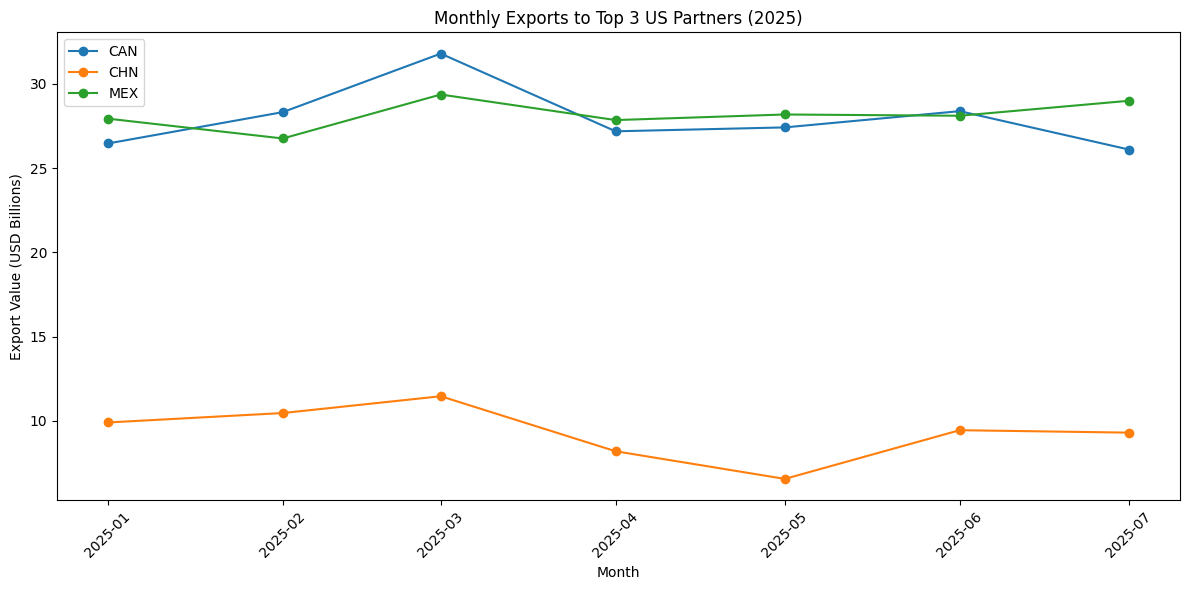

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

for destination in monthly_exports_top_partners['destination'].unique():
    partner_data = monthly_exports_top_partners[monthly_exports_top_partners['destination'] == destination]
    ax.plot(partner_data['month'], partner_data['value'], marker='o', linestyle='-', label=destination)

ax.set_xlabel("Month")
ax.set_ylabel("Export Value (USD Billions)")
ax.set_title("Monthly Exports to Top 3 US Partners (2025)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Summary:

### Data Analysis Key Findings

* The top 3 export partners for the USA based on total export value across all months are Mexico (MEX), Canada (CAN), and China (CHN).
* The monthly export values to the top 3 partners in 2025 range from approximately \$27 billion to over \$35 billion for Canada, around \$35 billion to nearly \$40 billion for Mexico, and approximately \$10 billion to over \$13 billion for China.

### Insights or Next Steps

* The plot visually confirms that Mexico and Canada are significantly larger export markets for the USA compared to China in 2025, based on the provided data.
* Further analysis could involve investigating the specific products or industries contributing most to the export values for each of these top partners and analyzing year-over-year trends.
